In [34]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from astropy.io import fits
from astropy.table import Table

from astropy import units as u

In [2]:
# plotting parameters
plt.rc('axes', labelsize=10)
plt.rc('axes', labelweight='regular')
plt.rc('axes', titleweight='regular')
plt.rc('axes', linewidth=1)
plt.rc('xtick',labelsize=10,direction='in',top=True)
plt.rc('ytick',labelsize=10,direction='in',right=True)
plt.rcParams['xtick.major.pad']='10'
plt.rcParams['ytick.major.pad']='10'

paper_params = {'text.usetex' : True,
           'font.size' : 14,
           'font.family' : 'lmodern',
           'figure.dpi' : 200,
           }
plt.rcParams.update(paper_params)
## 3.5 x 3 inch figure size for single column in paper
## 7 x 3 inch figure size for two column in paper

In [ ]:
# 4MOST directory

In [ ]:
# read in the big 4MOST data file (800 MB) of gzipped csv

In [3]:
#PLATO data
plato_dir = '/Users/dimoff/Radiogenic_Heating/PLATO_data/'
plato_VMP_subsample_file = 'VMP_PLATO_2143subsample.fits'

In [4]:
# use fits io to read the plato data
plato_VMP_subsample = fits.open(plato_dir + plato_VMP_subsample_file)[1].data
plato_VMP_subsample = Table(plato_VMP_subsample)

In [9]:
for column in plato_VMP_subsample.colnames:
    print(column)

NAME
RA_1
DEC_1
PMRA
PMDEC
EPOCH
RESOLUTION
SUBSURVEY
CADENCE
TEMPLATE
RULESET
REDSHIFT_ESTIMATE
REDSHIFT_ERROR
EXTENT_FLAG
EXTENT_PARAMETER
EXTENT_INDEX
MAG
MAG_ERR
MAG_TYPE
REDDENING
TEMPLATE_REDSHIFT
DATE_EARLIEST
DATE_LATEST
CAL_MAG_BLUE
CAL_MAG_ERR_BLUE
CAL_MAG_ID_BLUE
CAL_MAG_GREEN
CAL_MAG_ERR_GREEN
CAL_MAG_ID_GREEN
CAL_MAG_RED
CAL_MAG_ERR_RED
CAL_MAG_ID_RED
CLASSIFICATION
COMPLETENESS
PARALLAX
source_id
RA_2
DEC_2
BP
p0
G_0
mh_xgboost
teff_xgboost
logg_xgboost
Separation


In [58]:
# as a note, the solar nu_max value is < 500. 

In [ ]:
nu_maxes = [] # units fall out in micro hz
for teff, logg in zip(plato_VMP_subsample['teff_xgboost'], plato_VMP_subsample['logg_xgboost']):
    nu_maxes.append(10**logg / np.sqrt(teff))
nu_maxes = np.array(nu_maxes)

In [57]:
print(np.nanmax(nu_maxes),np.nanmean(nu_maxes),np.nanmin(nu_maxes))

32.876083 3.7871087 0.04813161


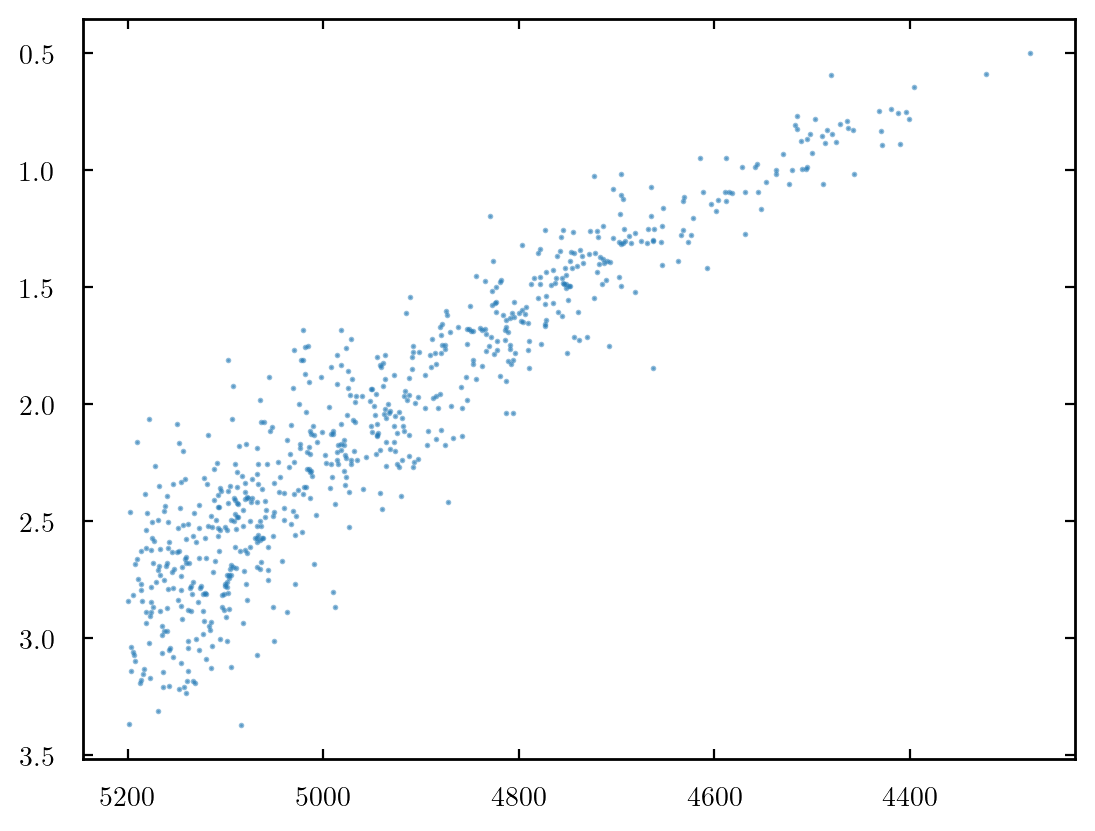

In [16]:
plt.scatter(plato_VMP_subsample['teff_xgboost'], plato_VMP_subsample['logg_xgboost'], s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

In [7]:
plato_VMP_subsample['MAG'].min(), plato_VMP_subsample['MAG'].max()

(np.float32(7.926697), np.float32(15.982954))

1307

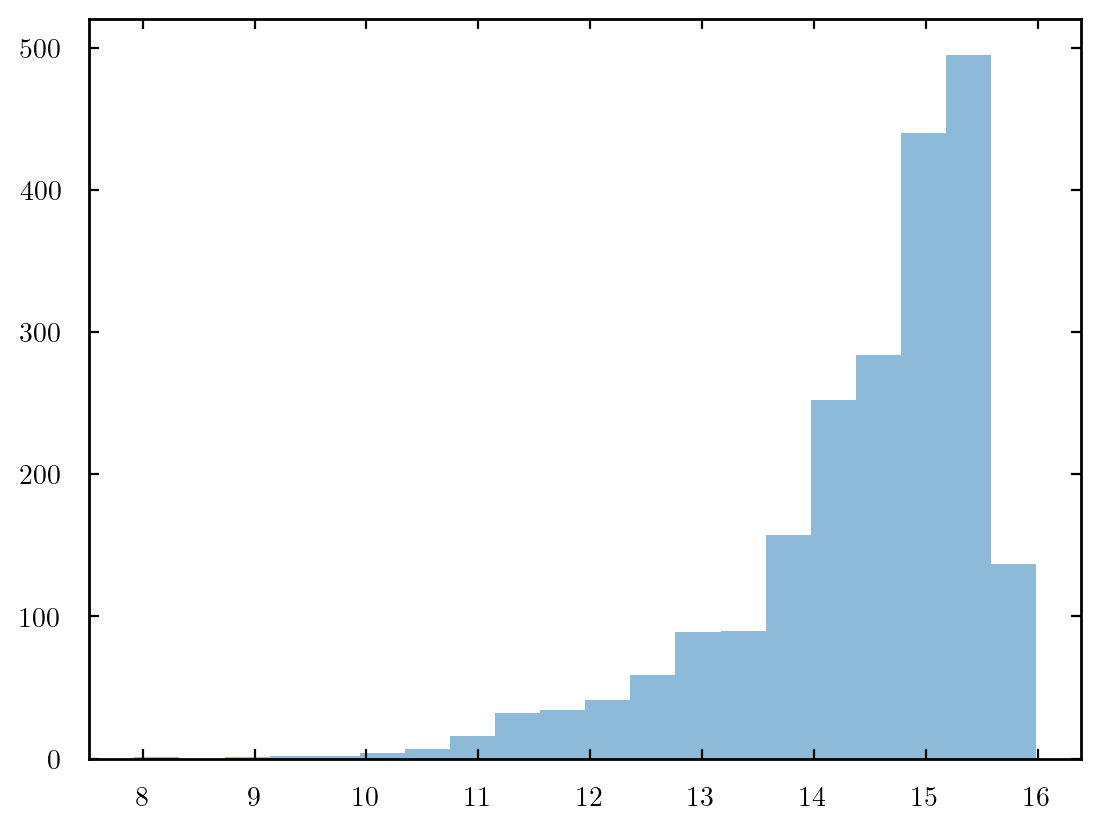

In [17]:
plt.hist(plato_VMP_subsample['MAG'], bins=20, alpha=0.5)
# how many are brighter than 15th magnitude?
len(plato_VMP_subsample[plato_VMP_subsample['MAG'] < 15])

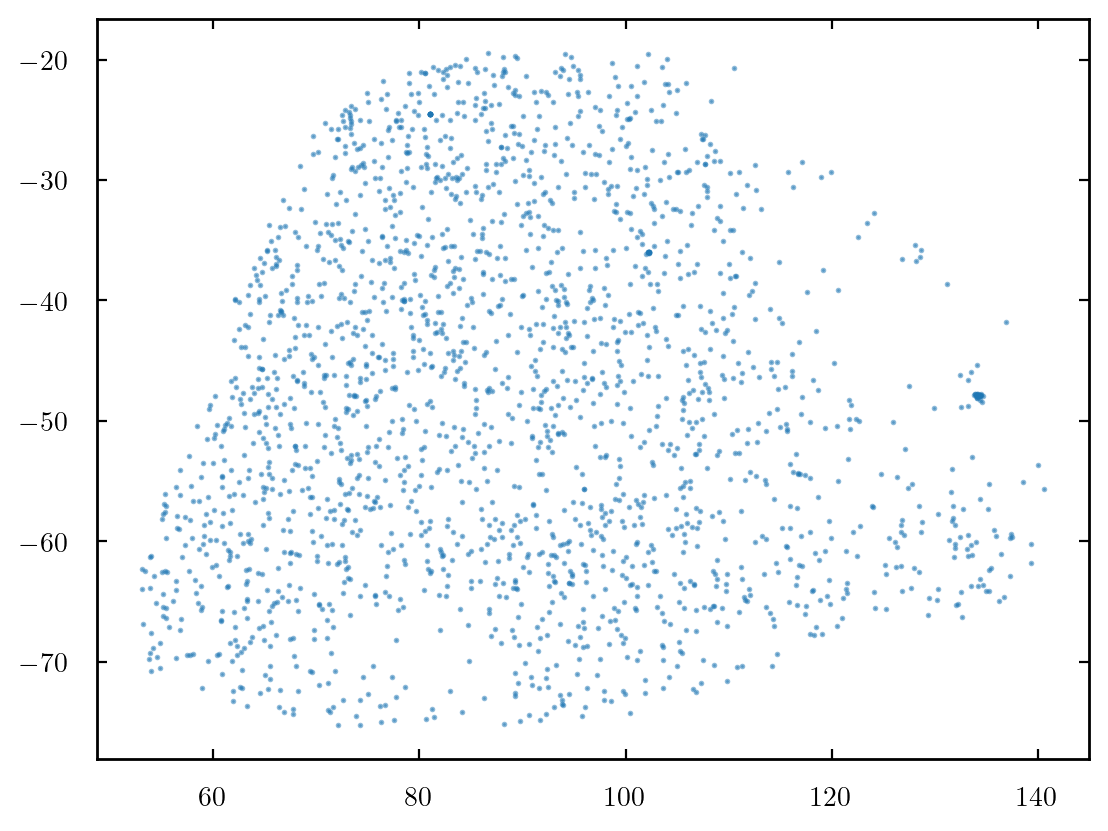

In [12]:
plt.scatter(plato_VMP_subsample['RA_1'], plato_VMP_subsample['DEC_1'], s=1, alpha=0.5)

In [73]:
## write function to convert the SAGA RA and DEC from sexagesimal to decimal degrees
#def sexagesimal_to_decimal(ra, dec):
#    # convert RA from sexagesimal to decimal degrees
#    ra_h = ra[0:2]
#    ra_m = ra[3:5]
#    ra_s = ra[6:11]
#    ra_decimal = (float(ra_h) + float(ra_m)/60 + float(ra_s)/3600) * 15
#    
#    # convert DEC from sexagesimal to decimal degrees
#    dec_sign = 1
#    if dec[0] == '-':
#        dec_sign = -1
#        dec = dec[1:]
#    dec_d = dec[0:2]
#    dec_m = dec[3:5]
#    dec_s = dec[6:11]
#    dec_decimal = dec_sign * (float(dec_d) + float(dec_m)/60 + float(dec_s)/3600)
#    
#    return ra_decimal, dec_decimal

In [74]:
# re-write RA and DEC for the SAGA data
#K_RA_decimal = []; K_DEC_decimal = []
#Th_RA_decimal = []; Th_DEC_decimal = []
#U_RA_decimal = []; U_DEC_decimal = []
#Eu_RA_decimal = []; Eu_DEC_decimal = []
#
#for i in range(len(K_name)):
#    if K_RA[i] == '':
#        K_RA_decimal.append(np.nan)
#        K_DEC_decimal.append(np.nan)
#        continue
#    ra, dec = sexagesimal_to_decimal(K_RA[i], K_DEC[i])
#    K_RA_decimal.append(ra)
#    K_DEC_decimal.append(dec)
#for i in range(len(Th_name)):
#    if Th_RA[i] == '':
#        Th_RA_decimal.append(np.nan)
#        Th_DEC_decimal.append(np.nan)
#        continue
#    ra, dec = sexagesimal_to_decimal(Th_RA[i], Th_DEC[i])
#    Th_RA_decimal.append(ra)
#    Th_DEC_decimal.append(dec)
#for i in range(len(U_name)):
#    if U_RA[i] == '':
#        U_RA_decimal.append(np.nan)
#        U_DEC_decimal.append(np.nan)
#        continue
#    ra, dec = sexagesimal_to_decimal(U_RA[i], U_DEC[i])
#    U_RA_decimal.append(ra)
#    U_DEC_decimal.append(dec)
#for i in range(len(Eu_name)):   
#    if Eu_RA[i] == '':
#        Eu_RA_decimal.append(np.nan)
#        Eu_DEC_decimal.append(np.nan)
#        continue
#    ra, dec = sexagesimal_to_decimal(Eu_RA[i], Eu_DEC[i])
#    Eu_RA_decimal.append(ra)
#    Eu_DEC_decimal.append(dec)

In [75]:
# read the 4MOST catalog
_4MOST_dir = '/Users/dimoff/Documents/MPIA/MARIA/4MOST/'
_4MOST_files = !ls {_4MOST_dir}*.fits

hdul = fits.open(_4MOST_files[0])
_4MOST_data = Table(hdul[1].data)
print(_4MOST_data.columns)

<TableColumns names=('NAME','RA','DEC','PMRA','PMDEC','EPOCH','RESOLUTION','SUBSURVEY','CADENCE','TEMPLATE','RULESET','REDSHIFT_ESTIMATE','REDSHIFT_ERROR','EXTENT_FLAG','EXTENT_PARAMETER','EXTENT_INDEX','MAG','MAG_ERR','MAG_TYPE','REDDENING','TEMPLATE_REDSHIFT','DATE_EARLIEST','DATE_LATEST','CAL_MAG_BLUE','CAL_MAG_ERR_BLUE','CAL_MAG_ID_BLUE','CAL_MAG_GREEN','CAL_MAG_ERR_GREEN','CAL_MAG_ID_GREEN','CAL_MAG_RED','CAL_MAG_ERR_RED','CAL_MAG_ID_RED','CLASSIFICATION','COMPLETENESS','PARALLAX')>


In [76]:
len(K_name), len(Th_name), len(U_name), len(Eu_name), len(_4MOST_data)

(411, 503, 14, 2473, 3638780)

In [ ]:
# cross match RA and DEC between the SAGA data and the 4MOST catalog to find common stars and find which stars in the 4MOST catalog are in the SAGA data
for i in tqdm(range(len(U_name)), desc='Matching U-element stars'):
    for j in range(len(_4MOST_data)):
        if np.isclose(U_RA_decimal[i], _4MOST_data['RA'][j], atol=1/3600) and np.isclose(U_DEC_decimal[i], _4MOST_data['DEC'][j], atol=1/3600):
            print(f"Found match for {U_name[i]} in 4MOST catalog: {_4MOST_data['NAME'][j]}. \n \
                  U_RA: {U_RA_decimal[i]}, U_DEC: {U_DEC_decimal[i]}. \n \
                  4MOST_RA: {_4MOST_data['RA'][j]}, 4MOST_DEC: {_4MOST_data['DEC'][j]}. \n \
                  U_teff: {U_teff[i]}, U_logg: {U_logg[i]}, U_Met: {U_Met[i]}, U_FeH: {U_FeH[i]}, U_KFe: {U_KFe[i]}. ")

Matching U-element stars:  14%|█▍        | 2/14 [00:48<04:50, 24.17s/it]

Found match for CS22892-052 in 4MOST catalog: 6826025986350385280. 
                   U_RA: 334.2569166666667, U_DEC: -16.657527777777776. 
                   4MOST_RA: 334.25695654634, 4MOST_DEC: -16.65754332147. 
                   U_teff: 4790, U_logg: 1.6, U_Met: -2.92, U_FeH: -2.91+-0.14, U_KFe: <1.53. 
Found match for CS22892-052 in 4MOST catalog: 6826025986350385280. 
                   U_RA: 334.2569166666667, U_DEC: -16.657527777777776. 
                   4MOST_RA: 334.25695654634, 4MOST_DEC: -16.65754332147. 
                   U_teff: 4790, U_logg: 1.6, U_Met: -2.92, U_FeH: -2.91+-0.14, U_KFe: <1.53. 


Matching U-element stars:  29%|██▊       | 4/14 [01:36<04:01, 24.18s/it]

Found match for CS31082-001 in 4MOST catalog: 2451773941958712192. 
                   U_RA: 22.37975, U_DEC: -16.01263888888889. 
                   4MOST_RA: 22.37976737421, 4MOST_DEC: -16.01282775355. 
                   U_teff: 4825, U_logg: 1.5, U_Met: -2.9, U_FeH: -2.9, U_KFe: 1.52. 
Found match for CS31082-001 in 4MOST catalog: 2451773941958712192. 
                   U_RA: 22.37975, U_DEC: -16.01263888888889. 
                   4MOST_RA: 22.37976737421, 4MOST_DEC: -16.01282775355. 
                   U_teff: 4825, U_logg: 1.5, U_Met: -2.9, U_FeH: -2.9, U_KFe: 1.52. 


Matching U-element stars:  50%|█████     | 7/14 [02:49<02:49, 24.21s/it]

...

Matching U-element stars:  86%|████████▌ | 12/14 [04:49<00:48, 24.07s/it]

Found match for RAVEJ203843.2-002333 in 4MOST catalog: 4226556850750887168. 
                   U_RA: 309.68, U_DEC: -0.3925. 
                   4MOST_RA: 309.67995041579, 4MOST_DEC: -0.39250625296. 
                   U_teff: 4630, U_logg: 1.2, U_Met: -2.91, U_FeH: -2.93+-0.05, U_KFe: 1.31+-0.2. 


Matching U-element stars:  93%|█████████▎| 13/14 [05:13<00:24, 24.02s/it]

Found match for SMSSJ200322.54-114203.3 in 4MOST catalog: 4190620966764303488. 
                   U_RA: 300.843875, U_DEC: -11.700772222222222. 
                   4MOST_RA: 300.84393192485, 4MOST_DEC: -11.70097993036. 
                   U_teff: 5175, U_logg: 2.44, U_Met: -3.5, U_FeH: -3.57+-0.11, U_KFe: 2.2+-0.16. 


Matching U-element stars: 100%|██████████| 14/14 [05:37<00:00, 24.09s/it]


In [79]:
# cross match RA and DEC between the SAGA data and the 4MOST catalog to find common stars and find which stars in the 4MOST catalog are in the SAGA data
for i in range(len(K_name)): #tqdm(range(len(K_name)), desc='Matching K-element stars'):
    for j in range(len(_4MOST_data)):
        if np.isclose(K_RA_decimal[i], _4MOST_data['RA'][j], atol=1/3600) and np.isclose(K_DEC_decimal[i], _4MOST_data['DEC'][j], atol=1/3600):
            print(f"Found match for {K_name[i]} in 4MOST catalog: {_4MOST_data['NAME'][j]}. \n \
                  K_RA: {K_RA_decimal[i]}, K_DEC: {K_DEC_decimal[i]}. \n \
                  4MOST_RA: {_4MOST_data['RA'][j]}, 4MOST_DEC: {_4MOST_data['DEC'][j]}. \n \
                  K_teff: {K_teff[i]}, K_logg: {K_logg[i]}, K_Met: {K_Met[i]}, K_FeH: {K_FeH[i]}, K_KFe: {K_KFe[i]}. ")


Found match for 2M22045404-1148287 in 4MOST catalog: 2613467159867601152. 
                   K_RA: 331.22516666666667, K_DEC: -11.807975. 
                   4MOST_RA: 331.22517014284, 4MOST_DEC: -11.80800486128. 
                   K_teff: 4578, K_logg: 1.64, K_Met: -1.26, K_FeH: -1.26, K_KFe: 0.21+-0.2. 
Found match for 2MJ12091322-1415313 in 4MOST catalog: 3570484520225300352. 
                   K_RA: 182.30508333333336, K_DEC: -14.258722222222222. 
                   4MOST_RA: 182.30511655999, 4MOST_DEC: -14.25877471063. 
                   K_teff: 4370, K_logg: 0.56, K_Met: -2.11, K_FeH: -2.11+-0.01, K_KFe: 0.48+-0.1. 
Found match for 2MJ13254554-1747547 in 4MOST catalog: 3604042504162287232. 
                   K_RA: 201.43975, K_DEC: -17.798527777777778. 
                   4MOST_RA: 201.43960971893, 4MOST_DEC: -17.79864628074. 
                   K_teff: 4588, K_logg: 0.83, K_Met: -2.32, K_FeH: -2.32+-0.01, K_KFe: 0.47+-0.1. 
Found match for 2MJ13431929-2358139 in 4MOST catal

In [80]:
# cross match RA and DEC between the SAGA data and the 4MOST catalog to find common stars and find which stars in the 4MOST catalog are in the SAGA data
for i in range(len(Th_name)): #tqdm(range(len(Th_name)), desc='Matching Th-element stars'):
    for j in range(len(_4MOST_data)):
        if np.isclose(Th_RA_decimal[i], _4MOST_data['RA'][j], atol=1/3600) and np.isclose(Th_DEC_decimal[i], _4MOST_data['DEC'][j], atol=1/3600):
            print(f"Found match for {Th_name[i]} in 4MOST catalog: {_4MOST_data['NAME'][j]}. \n \
                  Th_RA: {Th_RA_decimal[i]}, Th_DEC: {Th_DEC_decimal[i]}. \n \
                  4MOST_RA: {_4MOST_data['RA'][j]}, 4MOST_DEC: {_4MOST_data['DEC'][j]}. \n \
                  Th_teff: {Th_teff[i]}, Th_logg: {Th_logg[i]}, Th_Met: {Th_Met[i]}, Th_FeH: {Th_FeH[i]}, Th_KFe: {Th_KFe[i]}. ")


Found match for BD-15_5781 in 4MOST catalog: 6887351938881045504. 
                   Th_RA: 311.39374999999995, Th_DEC: -14.520833333333334. 
                   4MOST_RA: 311.39394871828, 4MOST_DEC: -14.52097008239. 
                   Th_teff: 4550, Th_logg: 0.7, Th_Met: -2.87, Th_FeH: -2.92+-0.15, Th_KFe: 0.13+-0.36. 
Found match for BD-20_6008 in 4MOST catalog: 6857966322398347008. 
                   Th_RA: 310.7029166666667, Th_DEC: -20.010833333333334. 
                   4MOST_RA: 310.70313906588, 4MOST_DEC: -20.0109723454. 
                   Th_teff: 4540, Th_logg: 0.65, Th_Met: -3.05, Th_FeH: -3+-0.15, Th_KFe: <0.52. 
Found match for CS22166-016 in 4MOST catalog: 2372010867355028608. 
                   Th_RA: 14.599333333333334, Th_DEC: -14.78525. 
                   4MOST_RA: 14.59948230771, 4MOST_DEC: -14.78531531244. 
                   Th_teff: 4900, Th_logg: 1.75, Th_Met: -3.09, Th_FeH: -3.22+-0.15, Th_KFe: <1.21. 
Found match for CS22169-035 in 4MOST catalog: 31894385

In [81]:
# cross match RA and DEC between the SAGA data and the 4MOST catalog to find common stars and find which stars in the 4MOST catalog are in the SAGA data
for i in range(len(Eu_name)): #tqdm(range(len(Eu_name)), desc='Matching Eu-element stars'):
    for j in range(len(_4MOST_data)):
        if np.isclose(Eu_RA_decimal[i], _4MOST_data['RA'][j], atol=1/3600) and np.isclose(Eu_DEC_decimal[i], _4MOST_data['DEC'][j], atol=1/3600):
            print(f"Found match for {Eu_name[i]} in 4MOST catalog: {_4MOST_data['NAME'][j]}. \n \
                  Eu_RA: {Eu_RA_decimal[i]}, Eu_DEC: {Eu_DEC_decimal[i]}. \n \
                  4MOST_RA: {_4MOST_data['RA'][j]}, 4MOST_DEC: {_4MOST_data['DEC'][j]}. \n \
                  Eu_teff: {Eu_teff[i]}, Eu_logg: {Eu_logg[i]}, Eu_Met: {Eu_Met[i]}, Eu_FeH: {Eu_FeH[i]}, Eu_KFe: {Eu_KFe[i]}. ")


Found match for 2M22045404-1148287 in 4MOST catalog: 2613467159867601152. 
                   Eu_RA: 331.22516666666667, Eu_DEC: -11.807975. 
                   4MOST_RA: 331.22517014284, 4MOST_DEC: -11.80800486128. 
                   Eu_teff: 4578, Eu_logg: 1.64, Eu_Met: -1.26, Eu_FeH: -1.26, Eu_KFe: 0.42+-0.13. 
Found match for 2MASSJ02031860-7930291 in 4MOST catalog: 4632302346781151488. 
                   Eu_RA: 30.8275, Eu_DEC: -79.50808333333333. 
                   4MOST_RA: 30.82750463903, 4MOST_DEC: -79.50810097333. 
                   Eu_teff: 4720, Eu_logg: 1.1, Eu_Met: -3.03, Eu_FeH: -3.03, Eu_KFe: 0.36. 
Found match for 2MASSJ10242264-2904203 in 4MOST catalog: 5461712380484527104. 
                   Eu_RA: 156.09433333333334, Eu_DEC: -29.072305555555555. 
                   4MOST_RA: 156.09435499358, 4MOST_DEC: -29.07233316371. 
                   Eu_teff: 4720, Eu_logg: 1.3, Eu_Met: -3.13, Eu_FeH: -3.13, Eu_KFe: <1.21. 
Found match for 2MASSJ10275895-3006391 in 4MOST c